# Hello, KAN!

### Kolmogorov-Arnold representation theorem

Kolmogorov-Arnold representation theorem states that if $f$ is a multivariate continuous function
on a bounded domain, then it can be written as a finite composition of continuous functions of a
single variable and the binary operation of addition. More specifically, for a smooth $f : [0,1]^n \to \mathbb{R}$,


$$f(x) = f(x_1,...,x_n)=\sum_{q=1}^{2n+1}\Phi_q(\sum_{p=1}^n \phi_{q,p}(x_p))$$

where $\phi_{q,p}:[0,1]\to\mathbb{R}$ and $\Phi_q:\mathbb{R}\to\mathbb{R}$. In a sense, they showed that the only true multivariate function is addition, since every other function can be written using univariate functions and sum. However, this 2-Layer width-$(2n+1)$ Kolmogorov-Arnold representation may not be smooth due to its limited expressive power. We augment its expressive power by generalizing it to arbitrary depths and widths.

### Kolmogorov-Arnold Network (KAN)

The Kolmogorov-Arnold representation can be written in matrix form

$$f(x)={\bf \Phi}_{\rm out}\circ{\bf \Phi}_{\rm in}\circ {\bf x}$$

where 

$${\bf \Phi}_{\rm in}= \begin{pmatrix} \phi_{1,1}(\cdot) & \cdots & \phi_{1,n}(\cdot) \\ \vdots & & \vdots \\ \phi_{2n+1,1}(\cdot) & \cdots & \phi_{2n+1,n}(\cdot) \end{pmatrix},\quad {\bf \Phi}_{\rm out}=\begin{pmatrix} \Phi_1(\cdot) & \cdots & \Phi_{2n+1}(\cdot)\end{pmatrix}$$

We notice that both ${\bf \Phi}_{\rm in}$ and ${\bf \Phi}_{\rm out}$ are special cases of the following function matrix ${\bf \Phi}$ (with $n_{\rm in}$ inputs, and $n_{\rm out}$ outputs), we call a Kolmogorov-Arnold layer:

$${\bf \Phi}= \begin{pmatrix} \phi_{1,1}(\cdot) & \cdots & \phi_{1,n_{\rm in}}(\cdot) \\ \vdots & & \vdots \\ \phi_{n_{\rm out},1}(\cdot) & \cdots & \phi_{n_{\rm out},n_{\rm in}}(\cdot) \end{pmatrix}$$

${\bf \Phi}_{\rm in}$ corresponds to $n_{\rm in}=n, n_{\rm out}=2n+1$, and ${\bf \Phi}_{\rm out}$ corresponds to $n_{\rm in}=2n+1, n_{\rm out}=1$.

After defining the layer, we can construct a Kolmogorov-Arnold network simply by stacking layers! Let's say we have $L$ layers, with the $l^{\rm th}$ layer ${\bf \Phi}_l$ have shape $(n_{l+1}, n_{l})$. Then the whole network is

$${\rm KAN}({\bf x})={\bf \Phi}_{L-1}\circ\cdots \circ{\bf \Phi}_1\circ{\bf \Phi}_0\circ {\bf x}$$

In constrast, a Multi-Layer Perceptron is interleaved by linear layers ${\bf W}_l$ and nonlinearities $\sigma$:

$${\rm MLP}({\bf x})={\bf W}_{L-1}\circ\sigma\circ\cdots\circ {\bf W}_1\circ\sigma\circ {\bf W}_0\circ {\bf x}$$

A KAN can be easily visualized. (1) A KAN is simply stack of KAN layers. (2) Each KAN layer can be visualized as a fully-connected layer, with a 1D function placed on each edge. Let's see an example below.

### Get started with KANs

Initialize KAN

In [ ]:
from kan import *
# 设置精度为64位浮点数
torch.set_default_dtype(torch.float64)
# 选择计算设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
# 创建一个KAN模型
# 输入维度为2，输出维度为1，隐藏层有5个神经元，使用三次样条（k=3），网格间隔为5。
# 随机种子为42
# create a KAN: 2D inputs, 1D output, and 5 hidden neurons. cubic spline (k=3), 5 grid intervals (grid=5).
model = KAN(width=[2,5,1], grid=3, k=3, seed=42, device=device)

cpu
checkpoint directory created: ./model
saving model version 0.0


Create dataset

In [2]:
from kan.utils import create_dataset
# create dataset f(x,y) = exp(sin(pi*x)+y^2)
# 定义目标输出函数
f = lambda x: x[:,[0]] * x[:,[1]]#f(x,y)=x*y
#f = lambda x: torch.exp(torch.sin(torch.pi*x[:,[0]]) + x[:,[1]]**2)
# 创建数据集，输入维度为2
dataset = create_dataset(f, n_var=2, device=device)
#打印训练样本输入形状（样本数量，输入维度）和标签形状（样本数量，输出维度）
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 2]), torch.Size([1000, 1]))

dataset display

In [3]:
dataset ['train_input'],dataset ['train_label']

(tensor([[ 0.9401,  0.9797],
         [ 0.4156, -0.9600],
         [-0.0812, -0.1531],
         ...,
         [ 0.7357,  0.5217],
         [-0.4637, -0.7196],
         [ 0.5701, -0.4481]]),
 tensor([[ 9.2099e-01],
         [-3.9902e-01],
         [ 1.2433e-02],
         [-7.3016e-01],
         [-2.1574e-01],
         [-1.7579e-01],
         [ 2.8585e-01],
         [-4.7147e-04],
         [ 3.0161e-02],
         [ 3.5838e-01],
         [ 7.0439e-02],
         [ 5.3293e-01],
         [-5.9919e-03],
         [-9.5971e-02],
         [-1.2690e-02],
         [ 8.6433e-02],
         [-1.3939e-01],
         [ 1.8115e-01],
         [ 2.4587e-02],
         [-4.4778e-03],
         [ 4.2846e-01],
         [ 3.4850e-01],
         [ 3.4705e-01],
         [ 2.0160e-02],
         [ 1.0559e-01],
         [-6.6722e-02],
         [ 1.1933e-01],
         [ 1.8123e-01],
         [-4.6179e-01],
         [-6.1957e-02],
         [ 4.3142e-02],
         [-9.3246e-02],
         [ 2.8504e-01],
         [-5.3048e

Plot KAN at initialization

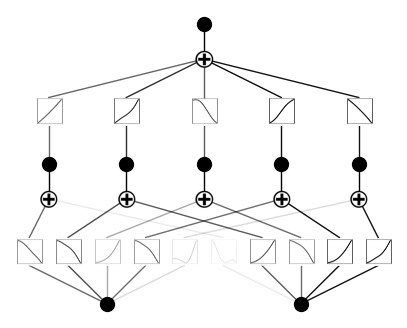

In [4]:
# plot KAN at initialization
# 利用train_input数据进行前向传播
model(dataset['train_input']);
# 绘制KAN模型初始状态
model.plot()

Train KAN with sparsity regularization

In [5]:
# train the model
model.fit(dataset, opt="LBFGS", steps=50, lamb=0.001);

| train_loss: 5.00e-03 | test_loss: 5.23e-03 | reg: 6.57e+00 | : 100%|█| 50/50 [00:20<00:00,  2.44it

saving model version 0.1


Plot trained KAN

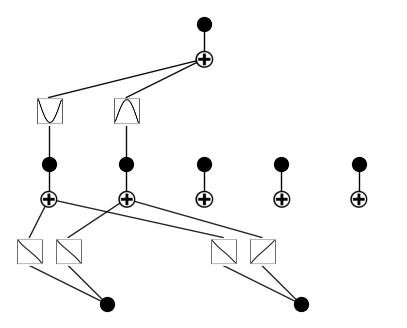

In [6]:
model.plot()

Prune KAN and replot

saving model version 0.2


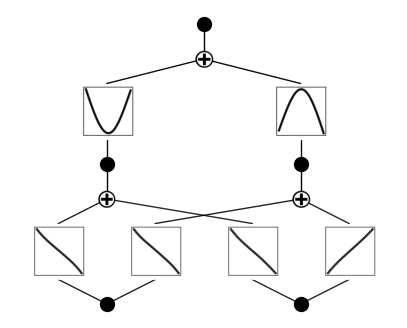

In [7]:
# 模型细化展示
model = model.prune()
model.plot()

Continue training and replot

| train_loss: 3.10e-04 | test_loss: 3.63e-04 | reg: 8.32e+00 | : 100%|█| 50/50 [00:09<00:00,  5.27it


saving model version 0.3


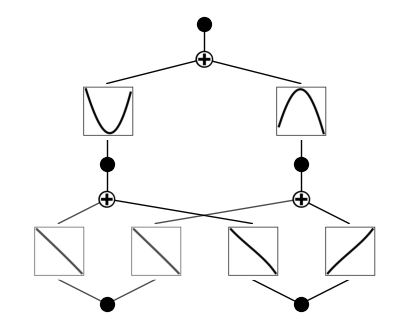

In [8]:
# 使用LBFGS优化器，模型参数更新次数50
model.fit(dataset, opt="LBFGS", steps=50);
model.plot()

In [9]:
# 网格细化 - 增加 B 样条基函数的网格分辨率，让激活函数学习更复杂的形状
model = model.refine(10)

saving model version 0.4


| train_loss: 1.12e-05 | test_loss: 1.31e-05 | reg: 8.31e+00 | : 100%|█| 50/50 [00:12<00:00,  4.06it


saving model version 0.5


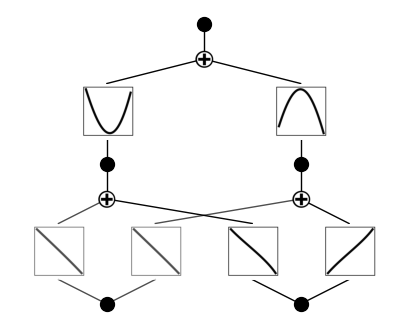

In [10]:
# 再次进行训练
model.fit(dataset, opt="LBFGS", steps=50);
model.plot()

Automatically or manually set activation functions to be symbolic

In [ ]:
# 激活函数设置方式--替代B样条函数减少模型的复杂程度——需选择对应的模式，在ns模式下仅决定符号分支
mode = "manual" # "manual"
# manual：手动为每个神经元指定符号函数（层索引，输入神经元索引，输出神经元索引）
if mode == "manual":
    # manual mode
    # model.fix_symbolic(0,0,0,'sin');# 第0层（输入层)的第一个输入节点到下一层（第一隐藏层）的第0个节点设置为sin函数
    # model.fix_symbolic(0,1,0,'x^2');# 第0层（输入层）的第一个节点到下一层（输出层）的第0个节点设置为平方函数
    # model.fix_symbolic(1,0,0,'exp');# 第1层（隐藏层）的第一个节点到下一层（输出层）的第0个节点设置为指数函数
    model.fix_symbolic(0,0,0,'x');
    model.fix_symbolic(0,1,0,'x');
    model.fix_symbolic(0,0,1,'x');
    model.fix_symbolic(0,1,1,'x');
    model.fix_symbolic(1,0,0,'x^2');
    model.fix_symbolic(1,1,0,'x^2');
# auto：依据预定义的函数库，自动为每个神经元选择最佳的符号函数
elif mode == "auto":
    # automatic mode
    lib = ['x','x^2','x^3','x^4','exp','log','sqrt','tanh','sin','abs']
    model.auto_symbolic(lib=lib)

Best value at boundary.
r2 is 0.9997771098405767
saving model version 0.6
Best value at boundary.
r2 is 0.9979518056658668
saving model version 0.7
Best value at boundary.
r2 is 0.999894864958305
saving model version 0.8
Best value at boundary.
r2 is 0.9990883049120237
saving model version 0.9
r2 is 0.9970277292506381
saving model version 0.10
r2 is 0.9994772442714928
saving model version 0.11


Continue training till machine precision

| train_loss: 1.26e-08 | test_loss: 4.69e-09 | reg: 0.00e+00 | : 100%|█| 50/50 [00:02<00:00, 19.41it


saving model version 0.12


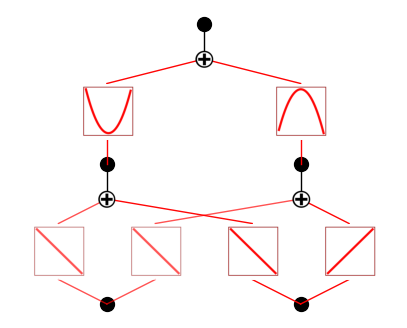

In [12]:
# 继续训练
model.fit(dataset, opt="LBFGS", steps=50);
model.plot()

Obtain the symbolic formula

In [13]:
from kan.utils import ex_round

ex_round(model.symbolic_formula()[0][0],4)

-0.651*(0.384*x_1 - x_2)**2 + 0.651*(0.384*x_1 + x_2)**2